In [ ]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# Stage 0: Data Preprocessing

For model training and testing, the original dataset `Table_S1.xlsx` was fully converted into numerical values based on different feature types using various tools by the authors. It can be saved as a CSV file and used for the 1000 balanced training datasets proposed in the paper, which were generated by undersampling non-essential genes to ensure an equal number of essential and non-essential samples in each dataset.

The first table in the original dataset `Table_S3.xlsx` provides model prediction results for *E. coli* K-12 MG1655, along with experimentally derived results from Baba et al., based on gene knockout experiments (*Construction of Escherichia coli K-12 in-frame, single-gene knockout mutants: the Keio collection*).

During preprocessing, I removed irrelevant fields (e.g., title, reference names), retaining only the column names and data. The cleaned dataset was converted to a CSV file for column renaming, using a simpler approach to distinguish columns across categories. It was then exported as `Table_S3_E_coli_Simplified.csv` for comparison during result reproduction.


In [ ]:
from IPython.display import display
import pandas as pd
import re

# Load the CSV file for result comparison
csv_file_path = '/content/drive/MyDrive/CSI5180_Project/Table_S3_E_coli.csv'
df_S3 = pd.read_csv(csv_file_path)

# Original column names (repeated in the same order for each category)
columns_original = [
    "Unique_ID (Reaction-gene pair)",
    "Reaction Name",
    "Gene ID",
    "Best Model Predicted",
    "%tage of 1000 models that predict a given gene to be essential",
    "Baba et. al 2006 6"
]

# Define the column names to keep (simplified version)
columns_simplified = [
    "Unique_ID",
    "Reaction_Name",
    "Gene_ID",
    "Best_Model_Classfication",
    "Essential_Predict_Percentage",
    "Reference_Classfication"
]

# Create a dictionary for column name mapping
column_mapping = dict(zip(columns_original, columns_simplified))

# Process a section of the dataframe by renaming columns, removing numerical suffixes, and adding a prefix.
def process_section(df_slice, prefix):
    # Use regex to remove the .number suffix at the end of column names
    clean_columns = [re.sub(r'\.\d+$', '', col) for col in df_slice.columns]

    # Create a copy to avoid modifying the original data
    df_processed = df_slice.copy()
    df_processed.columns = clean_columns

    # Apply column name mapping
    df_processed.rename(columns=column_mapping, inplace=True)

    # Add a prefix and replace spaces with underscores
    df_processed.columns = [
        f"{prefix}_{col}".replace(" ", "_")
        for col in df_processed.columns
    ]
    return df_processed

# Process the three sections
section_length = len(columns_original)
essential_df = process_section(df_S3.iloc[:, :section_length], "Essential")
nonessential_df = process_section(df_S3.iloc[:, section_length:2*section_length], "NonEssential")
unknown_df = process_section(df_S3.iloc[:, 2*section_length:3*section_length], "Unknown")

# Merge all sections and display the dataframe
df_simplified = pd.concat([essential_df, nonessential_df, unknown_df], axis=1)
display(df_simplified.reset_index(drop=True).head(5))

# Save as a new CSV file
final_csv_file_path = '/content/drive/MyDrive/CSI5180_Project/Table_S3_E_coli_Simplified.csv'
df_simplified.to_csv(final_csv_file_path, index=False)

,Essential_Unique_ID,Essential_Reaction_Name,Essential_Gene_ID,Essential_Best_Model_Classfication,Essential_Essential_Predict_Percentage,Essential_Reference_Classfication,NonEssential_Unique_ID,NonEssential_Reaction_Name,NonEssential_Gene_ID,NonEssential_Best_Model_Classfication,NonEssential_Essential_Predict_Percentage,NonEssential_Reference_Classfication,Unknown_Unique_ID,Unknown_Reaction_Name,Unknown_Gene_ID,Unknown_Best_Model_Classfication,Unknown_Essential_Predict_Percentage,Unknown_Reference_Classfication
0,FMNAT_b0025,FMNAT,b0025,E,100.0,E,NAt3_2pp_b0019,NAt3_2pp,b0019,N,0.0,N,ILETRS_b0026,ILETRS,b0026,E,98.5,ND
1,RBFK_b0025,RBFK,b0025,E,100.0,E,CRNCAR_b0036,CRNCAR,b0036,N,0.0,N,DPCOAK_b0103,DPCOAK,b0103,E,100.0,ND
2,DMPPS_b0029,DMPPS,b0029,E,100.0,E,CRNCDH_b0036,CRNCDH,b0036,N,0.0,N,ALATRS_b2697,ALATRS,b2697,E,98.1,ND
3,IPDPS_b0029,IPDPS,b0029,E,100.0,E,CRNCAL2_b0037,CRNCAL2,b0037,N,0.0,N,PGAMT_b3176,PGAMT,b3176,E,100.0,ND
4,DHDPRy_b0031,DHDPRy,b0031,E,100.0,E,CRNDCAL2_b0037,CRNDCAL2,b0037,N,0.0,N,PNTK_b3974,PNTK,b3974,E,100.0,ND


## Data Balancing via Undersampling
- 1000 balanced datasets via undersampling were obtained, ensuring that each dataset contains an equal number of *E* and *N* samples. These datasets are permanently saved in `/content/drive/MyDrive/CSI5180_Project/balanced_datasets`.

- To ensure reproducibility, `random_state=i` was used in the sampling and shuffling steps. This ensures that each iteration produces a consistent but distinct sample, maintaining diversity while keeping the process deterministic.

- **Undersampling Coverage Verification:** After 1000 iterations of undersampling, the majority class achieved a coverage of 100.00%, meaning that all instances were included at least once. This high-round random undersampling approach can also be mathematically proven in terms of the relationship between the number of iterations and the probability of full selection.

- These datasets serve as input for the SVM-RFE processing and locally optimal **feature combination (FC)** selection.

In [ ]:
import pandas as pd
import os

# Read the data
csv_file_path = '/content/drive/MyDrive/CSI5180_Project/Table_S1.csv'
df_S1 = pd.read_csv(csv_file_path)

# Split the DataFrame into majority and minority classes
df_majority = df_S1[df_S1["Class"] == "N"]  # Non-essential genes (majority class)
df_minority = df_S1[df_S1["Class"] == "E"]  # Essential genes (minority class)

n_minority = len(df_minority)
print("[Original Dataset]")
print(f"Minority class (E) sample count: {len(df_minority)}")
print(f"Majority class (N) sample count: {len(df_majority)}")

# Create the output directory
output_dir = '/content/drive/MyDrive/CSI5180_Project/balanced_datasets'
os.makedirs(output_dir, exist_ok=True)

# Initialize a set to record all indices of the sampled majority class samples
all_sampled_indices = set()

# Perform 1000 iterations of undersampling
for i in range(1000):
    # Randomly sample from the majority class to match the minority class count
    # random_state=i ensures reproducible sampling; each i gives a fixed but different sample.
    sampled_majority = df_majority.sample(n=n_minority, random_state=i)

    # Record the indices of the sampled majority samples
    all_sampled_indices.update(sampled_majority.index)

    # Combine the sampled majority data with the minority data and shuffle the dataset
    balanced_data = pd.concat([sampled_majority, df_minority])
    balanced_data = balanced_data.sample(frac=1, random_state=i).reset_index(drop=True)

    # Save the balanced dataset as a CSV file
    balanced_data.to_csv(os.path.join(output_dir, f"balanced_dataset_{i}.csv"), index=False)

# Calculate and print the coverage of majority class samples
coverage = len(all_sampled_indices) / len(df_majority)
print("\n[Undersampling]")
print(f"Majority class sample coverage: {coverage:.2%}")

[Original Dataset]
Minority class (E) sample count: 384
Majority class (N) sample count: 3120

[Undersampling]
Majority class sample coverage: 100.00%


# Stage 1: Locally Optimal Feature Combination (FC) Selection

In this stage, SVM-RFE is applied to 1000 balanced datasets using recursive feature elimination combined with 5-fold cross-validation to compute the auROC. For each dataset, RFE is used to obtain a feature ranking and the corresponding auROC for the top _n_ features (where _n_ ranges from 1 to 64). From these results, the best auROC and the corresponding optimal number of features (`best_n`) are determined.

Here, SVM-RFE is implemented as a custom function, with the underlying SVM model provided by cuML, which supports GPU acceleration. For small-scale data (768×64), the training speed can reach millisecond-level, faster than CPU-based methods. Although using RAPIDS cuML’s GPU acceleration in SVM-RFE does introduce a slight computational error, it is negligible since the primary concern is the relative ranking of features.

However, since the paper performed SVM-RFE using **WEKA version 3.8.40** and ultimately selected 26 BFC, which differs from my approach, the best feature combination (**BFC<sub>i</sub>**) generally corresponds to a `best_n` that is close to **64**. Therefore, further feature processing is required. Details of this process are provided in the subsequent section: **Locally Optimal Feature Combination (FC) Refinement**.

In [ ]:
# Install cuML (NVIDIA RAPIDS machine learning library, requires CUDA support)
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com

# Install CuPy (NumPy-compatible GPU-accelerated library, requires matching CUDA version)
!pip install cupy-cuda12x

In [ ]:
import cupy as cp
import numpy as np
import random
import os
import shutil

# Set random seeds to ensure reproducibility
RANDOM_STATE = 42
cp.random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Data storage location in Google Drive
drive_folder = '/content/drive/MyDrive/CSI5180_Project/balanced_datasets'
# Local storage location in Colab
local_folder = '/content/balanced_datasets'

# Ensure the local folder exists
os.makedirs(local_folder, exist_ok=True)

# Copy data to Colab local storage
shutil.copytree(drive_folder, local_folder, dirs_exist_ok=True)

print("Data has been copied to /content/balanced_datasets. Training will not be affected by Google Drive API limitations.")

Data has been copied to /content/balanced_datasets. Training will not be affected by Google Drive API limitations.


In [ ]:
import cupy as cp
from cuml.svm import LinearSVC
from cuml.metrics import roc_auc_score
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# ----------------
# Feature Ranker
# ----------------
class FeatureRanker:
    def __init__(self):
        self.estimator = LinearSVC(
            C=1,
            penalty='l2',
            loss='squared_hinge',
            max_iter=1000
        )

    def get_rank(self, X, y):
        """Perform SVM-RFE to obtain feature ranking.

        Args:
            X (cp.ndarray): Input features.
            y (cp.ndarray): Target labels.

        Returns:
            cp.ndarray: Ranking of features.
        """
        n_features = X.shape[1]
        rank = cp.ones(n_features, dtype=int)
        mask = cp.ones(n_features, dtype=bool)

        for step in range(n_features, 0, -1):
            # Select subset of features based on current mask
            X_sub = X[:, mask]
            self.estimator.fit(X_sub, y)
            coef = cp.abs(self.estimator.coef_).flatten()

            # If all feature weights are zero, add a small random noise
            # so that there is a slight non-zero difference between features.
            # This ensures subsequent ranking and elimination can proceed normally.
            if cp.all(coef == 0):
                coef += cp.random.uniform(0, 1e-6, coef.shape)

            idx = cp.argmin(coef)
            global_idx = cp.where(mask)[0][idx]
            rank[global_idx] = step
            mask[global_idx] = False

            del X_sub

        cp.get_default_memory_pool().free_all_blocks()
        return rank

# -------------------
# Feature Evaluator
# -------------------
class FeatureEvaluator:
    @staticmethod
    def evaluate_feature(X, y, feature_order, n_features):
        """Evaluate performance using a specified number of features via 5-fold cross-validation.

        Args:
            X (cp.ndarray): Input features.
            y (cp.ndarray): Target labels.
            feature_order (cp.ndarray): Feature indices ordered by importance.
            n_features (int): Number of top features to select.

        Returns:
            float: Average AUROC score from 5-fold CV used for comparing feature subsets in candidate datasets.
        """

        selected = feature_order[:n_features]
        X_sub = X[:, selected]

        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = []

        # Iterate over each fold
        for train_idx, test_idx in kf.split(X_sub.get()):
            X_train, X_test = X_sub[train_idx], X_sub[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = LinearSVC(C=1, max_iter=1000)
            model.fit(X_train, y_train)
            y_pred = model.decision_function(X_test)
            scores.append(roc_auc_score(y_test, y_pred))

            # Clean up GPU memory for current fold
            del model, X_train, X_test, y_train, y_test, y_pred

        cp.get_default_memory_pool().free_all_blocks()
        return np.mean(scores)

# --------------------------
# Data Processing Function
# --------------------------
def process_single_dataset_from_df(file_name, df, output_dir):
    """Process a single dataset from a DataFrame.

    This function performs feature ranking and evaluation,
    then returns the best feature selection scheme along with AUROC scores.

    Args:
        file_name (str): Name of the dataset file.
        df (pd.DataFrame): Input DataFrame.
        output_dir (str): Output directory (unused here but can be used for saving results).

    Returns:
        dict: Processed results including best number of features, best AUROC,
              feature ranking (column indices adjusted), and all AUROC scores.
    """

    try:
        # Extract features from columns 1 to -2, assuming first column is non-feature and last column is label
        X = cp.array(df.iloc[:, 1:-1].values, dtype=cp.float32)
        y = cp.array(df['Class'].map({'E': 1, 'N': 0}), dtype=cp.int32)

        # Normalize features: standard score normalization
        X = (X - cp.mean(X, axis=0)) / (cp.std(X, axis=0) + 1e-8)

        ranker = FeatureRanker()
        feature_order = cp.argsort(ranker.get_rank(X, y))[::-1]

        results = []
        # Evaluate performance for top n features, where n ranges from 1 to 64
        for n in range(1, 65):
            auc = FeatureEvaluator.evaluate_feature(X, y, feature_order, n)
            results.append({'n_features': n, 'auROC': auc})

        best_result = max(results, key=lambda x: x['auROC'])
        output = {
            'dataset': file_name,
            'best_n': best_result['n_features'],
            'best_auc': best_result['auROC'],
            # Adjust feature indices: add 1 so that column numbers match the ones in balanced_dataset_i
            'feature_rank': (cp.asnumpy(feature_order) + 1).tolist(),
            'all_auc': [r['auROC'] for r in results]
        }
        return output

    except Exception as e:
        print(f"Error processing {file_name}: {str(e)}")
        return {
            'dataset': file_name,
            'best_n': 0,
            'best_auc': 0.0,
            'feature_rank': [],
            'all_auc': []
        }
    finally:
        cp.get_default_memory_pool().free_all_blocks()

# -------------------------------
# Parallel Execution Controller
# -------------------------------
def batch_processing(input_dir, output_dir, start_idx, end_idx, max_workers=2):
    """Batch process datasets and compile a summary.

    Parameters:
        input_dir (str): Directory containing input CSV files.
        output_dir (str): Directory to save summary CSV.
        start_idx (int): Start index of files to process.
        end_idx (int): End index of files to process.
        max_workers (int): Maximum number of parallel workers.

    Returns:
        pd.DataFrame: Summary DataFrame of processed results.
    """

    # Set the active GPU device to GPU 0 (only needed once in a single-GPU environment)
    cp.cuda.Device(0).use()

    files = sorted(
        [f for f in os.listdir(input_dir) if f.endswith('.csv')],
        key=lambda x: int(x.split('_')[-1].split('.')[0])
    )
    batch_files = files[start_idx:end_idx+1]
    os.makedirs(output_dir, exist_ok=True)

    all_data = []
    for file in batch_files:
        file_path = os.path.join(input_dir, file)
        df = pd.read_csv(file_path)
        all_data.append((file, df))

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = []
        for file_name, df in all_data:
            future = executor.submit(process_single_dataset_from_df, file_name, df, output_dir)
            futures.append(future)

        # Display overall progress bar for batch processing
        results = []
        progress_bar = tqdm(futures,
                            desc=f"Processing batch {start_idx} to {end_idx}",
                            bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
        for f in progress_bar:
            results.append(f.result())

    valid_results = [r for r in results if r['best_n'] > 0]
    print(f"Successfully processed {len(valid_results)}/{len(batch_files)} datasets")

    summary = pd.DataFrame(valid_results)
    summary_filename = f"summary_{start_idx}_to_{end_idx}.csv"
    summary.to_csv(os.path.join(output_dir, summary_filename), index=False)
    print(f"Summary report saved: {summary_filename}")
    return summary

## Batch Processing and Global Evaluation Data Preparation

For a total of 1000 datasets, I perform batch processing by handling 50 datasets per batch (from index 0 to 999). The process is as follows:

1. **Batch Processing**:  
Each batch processes 50 datasets, and intermediate results for each batch are temporarily saved in the `/content/results` folder.

2. **Merging**:  
After processing all batches, the individual summary CSV files are merged into a single file named `summary_0_to_999.csv`.

3. **Final Storage**:  
The merged summary file is permanently saved to `/content/drive/MyDrive/CSI5180_Project/results`, serving as the input for Locally Optimal Feature Combination (FC) Refinement.

In [ ]:
import gc
import cupy as cp

# Define input and output directories for datasets and results.
input_folder = "/content/balanced_datasets"
output_folder = "/content/results"

def release_memory():
    """Release GPU and Python-related memory to prevent memory leakage."""
    # Free all unused memory blocks allocated by CuPy
    cp.get_default_memory_pool().free_all_blocks()

    # Trigger Python garbage collection to clean up unused objects
    gc.collect()

    print("Memory released successfully!")

In [ ]:
# Batch Processing Testing: Assume each batch processes 50 datasets.
# The following example processes datasets 0–49 and 50–99.

# Process first batch
batch_range = [0, 49]
start_idx, end_idx = batch_range
batch_summary = batch_processing(input_folder, output_folder, start_idx=start_idx, end_idx=end_idx, max_workers=1)

# Release memory
if "batch_summary" in locals():
    del batch_summary
release_memory()

# Process second batch
batch_range = [50, 99]
start_idx, end_idx = batch_range
batch_summary = batch_processing(input_folder, output_folder, start_idx=start_idx, end_idx=end_idx, max_workers=1)

# Release memory
if "batch_summary" in locals():
    del batch_summary
release_memory()

Processing batch 0 to 49: 100%|██████████| 50/50 [07:26<00:00]


Successfully processed 50/50 datasets
Summary report saved: summary_0_to_49.csv
Memory released successfully!


Processing batch 50 to 99: 100%|██████████| 50/50 [07:33<00:00]


Successfully processed 50/50 datasets
Summary report saved: summary_50_to_99.csv
Memory released successfully!


In [ ]:
# ---------------------------
# Main Batch Processing
# ---------------------------
# Batch process the remaining datasets, processing 50 at a time.
# Loop through dataset indices in steps of 50, from 100 to 999

for start_idx in range(100, 1000, 50):
    end_idx = min(start_idx + 49, 999)  # Ensure we don't exceed 999

    print(f"Processing batch {start_idx} to {end_idx} ...")
    batch_summary = batch_processing(input_folder, output_folder,
                                     start_idx=start_idx, end_idx=end_idx,
                                     max_workers=1)

    # Release memory after each batch
    if "batch_summary" in locals():
        del batch_summary
    release_memory()

print("All batches processed from 100 to 999.")

Processing batch 100 to 149 ...


Processing batch 100 to 149: 100%|██████████| 50/50 [07:27<00:00]


Successfully processed 50/50 datasets
Summary report saved: summary_100_to_149.csv
Memory released successfully!
Processing batch 150 to 199 ...


Processing batch 150 to 199: 100%|██████████| 50/50 [07:36<00:00]


Successfully processed 50/50 datasets
Summary report saved: summary_150_to_199.csv
Memory released successfully!
Processing batch 200 to 249 ...


...

Successfully processed 50/50 datasets
Summary report saved: summary_850_to_899.csv
Memory released successfully!
Processing batch 900 to 949 ...


Processing batch 900 to 949: 100%|██████████| 50/50 [07:26<00:00]


Successfully processed 50/50 datasets
Summary report saved: summary_900_to_949.csv
Memory released successfully!
Processing batch 950 to 999 ...


Processing batch 950 to 999: 100%|██████████| 50/50 [07:28<00:00]


Successfully processed 50/50 datasets
Summary report saved: summary_950_to_999.csv
Memory released successfully!
All batches processed from 100 to 999.


In [ ]:
import pandas as pd
import glob
import os

# Define input and output directories
input_folder = "/content/results"
output_folder = "/content/drive/MyDrive/CSI5180_Project/results"

# Ensure that the output folder exists
os.makedirs(output_folder, exist_ok=True)

# Scan the input_folder for all files matching "summary_*.csv"
csv_files = sorted(glob.glob(os.path.join(input_folder, "summary_*.csv")))

# Read and merge all CSV files
df_list = [pd.read_csv(file) for file in csv_files]
merged_df = pd.concat(df_list, ignore_index=True)

# Sort the merged dataframe by the 'dataset' column, extracting the numeric part from filenames like "balanced_dataset_i.csv"
merged_df['dataset_num'] = merged_df['dataset'].str.extract(r'balanced_dataset_(\d+)\.csv').astype(int)
merged_df = merged_df.sort_values(by='dataset_num').drop(columns=['dataset_num'])

# Define the final merged file path
output_file = os.path.join(output_folder, "summary_0_to_999.csv")

# Save the merged result
merged_df.to_csv(output_file, index=False)

## Locally Optimal Feature Combination (FC) Refinement

1. **Background**

- SVM-RFE ranks features, and the best auROC is typically reached when the number of features (`n`) is near 64 (with a minimum of 53).
- Using only `best_n` does not sufficiently remove low-contribution features.

2. **Motivation**

- As `n` increases, auROC eventually plateaus, indicating that additional features contribute little.
- To address this, we introduce the `best_k` metric:
  - `best_k` identifies the point where auROC growth stagnates.
  - It limits the feature count (capped at 60% of `best_n`), balancing performance with feature reduction.

3. **Impact on Global Evaluation**

- Selecting BFCs with `best_k` ensures that in the **Global Evaluation** stage:
  - Each dataset’s BFC not only achieves a high auROC but also maintains diversity in feature combinations.
  - This leads to more differentiated results, as limiting feature counts prevents all selections from converging around 64.

4. **Final Storage**:  

- The processed summary file, named `summary_best_k.csv`, is saved to `/content/drive/MyDrive/CSI5180_Project/results` and serves as part of the input for the global evaluation of best feature combinations (BFCs).

In [ ]:
import numpy as np
import pandas as pd
import cupy as cp
import random
import ast
import os
import shutil

# --------------------
# Optimal K Finder
# --------------------
def find_best_k(all_auc, min_coverage=0.9, max_tolerance=0.002, min_steps=3):
    """
    Determine the optimal k value (number of features) based on the auROC progression.

    Args:
        all_auc (list): List of auROC values for increasing numbers of features.
        min_coverage (float): Minimum fraction of max auROC to start candidate selection.
        max_tolerance (float): Maximum allowed increase in auROC to consider performance stagnant.
        min_steps (int): Minimum consecutive steps with low improvement required to stop.

    Returns:
        tuple: (candidate_k, candidate_auc)
            candidate_k: The optimal number of features.
            candidate_auc: The corresponding auROC at candidate_k.
    """
    max_auc = max(all_auc)
    target_auc = max_auc * min_coverage
    candidate_k = None
    candidate_auc = None
    stagnation_steps = 0
    prev_auc = None

    for idx, auc in enumerate(all_auc):
        # Record the first k that reaches target AUC
        if auc >= target_auc and candidate_k is None:
            candidate_k = idx + 1
            candidate_auc = auc
            prev_auc = auc

        # Continue tracking and update when performance plateaus
        if candidate_k is not None:
            if prev_auc is not None:
                delta = auc - prev_auc
                if delta <= max_tolerance:
                    stagnation_steps += 1
                    if stagnation_steps >= min_steps:
                        return candidate_k, candidate_auc  # Return when performance stagnates
                else:
                    stagnation_steps = 0
            # Update candidate if a higher auROC is observed
            if auc > candidate_auc:
                candidate_k = idx + 1
                candidate_auc = auc
            prev_auc = auc

    # If no clear plateau is detected, return the first k reaching target AUC (or 1 if none)
    return candidate_k or 1, candidate_auc or all_auc[-1]

# ----------------------------
# Summary File Processing
# ----------------------------
def process_summary_with_best_k():
    """
    Process the summary CSV file to compute and append 'best_k' and 'auc_for_k' columns.

    The function reads the summary file from the local folder (where 'summary_0_to_999.csv' has been copied),
    converts the 'all_auc' column from string to list if needed, computes the optimal feature count (best_k)
    for each dataset (capped at 60% of best_n), sorts the entries by 'auc_for_k', and saves the updated summary
    back to the drive folder.

    Returns:
        pd.DataFrame: The processed summary DataFrame with new columns.
    """
    # Define file paths
    drive_folder = '/content/drive/MyDrive/CSI5180_Project/results'

    input_file = 'summary_0_to_999.csv'
    output_name = 'summary_best_k.csv'

    # Read the summary file from the local folder
    summary_path = os.path.join(drive_folder, input_file)
    summary_df = pd.read_csv(summary_path)

    # Convert 'all_auc' from string to list if necessary
    if isinstance(summary_df['all_auc'].iloc[0], str):
        summary_df['all_auc'] = summary_df['all_auc'].apply(ast.literal_eval)

    # Remove existing 'best_k' and 'auc_for_k' columns if present
    summary_df = summary_df.drop(columns=['best_k', 'auc_for_k'], errors='ignore')

    def get_best_k(auc_list, best_n):
        """
        Compute best_k and corresponding auROC using find_best_k,
        and cap best_k at 60% of best_n.
        """
        k, auc_val = find_best_k(
            auc_list,
            min_coverage=0.9,
            max_tolerance=0.001,
            min_steps=4
        )
        upper_limit = int(best_n * 0.6)
        if k > upper_limit:
            k = upper_limit
        return pd.Series([k, auc_val])

    # Apply the get_best_k function row-wise using best_n
    summary_df[['best_k', 'auc_for_k']] = summary_df.apply(
        lambda row: get_best_k(row['all_auc'], row['best_n']),
        axis=1
    )

    # Sort the DataFrame by 'auc_for_k' in descending order
    summary_df.sort_values(by='auc_for_k', ascending=False, inplace=True)

    # Set the column order
    target_order = [
        'dataset', 'best_n', 'best_auc',
        'best_k', 'auc_for_k',
        'feature_rank', 'all_auc'
    ]
    remaining_columns = [col for col in summary_df.columns if col not in target_order]
    final_order = target_order + remaining_columns
    summary_df = summary_df[final_order]

    # Save the processed summary to the drive folder
    output_path = os.path.join(drive_folder, output_name)
    summary_df.to_csv(output_path, index=False)
    print(f"Processed summary saved to: {output_path}")
    return summary_df

# Execute processing and preview the result
processed_df = process_summary_with_best_k()
print("\nPreview of processed dataframe:")
print(processed_df[['dataset', 'best_n', 'best_auc', 'best_k', 'auc_for_k', 'feature_rank']].head())

Processed summary saved to: /content/drive/MyDrive/CSI5180_Project/results/summary_best_k.csv

Preview of processed dataframe:
                      dataset  best_n  best_auc  best_k  auc_for_k  \
703  balanced_dataset_703.csv      64  0.956787    38.0   0.956140   
710  balanced_dataset_710.csv      58  0.954493    34.0   0.954493   
307  balanced_dataset_307.csv      64  0.954851    38.0   0.953612   
24    balanced_dataset_24.csv      64  0.952940    38.0   0.952940   
580  balanced_dataset_580.csv      62  0.948704    37.0   0.948704   

                                          feature_rank  
703  [30, 24, 10, 49, 45, 61, 9, 62, 32, 51, 57, 55...  
710  [33, 13, 12, 42, 32, 46, 5, 45, 50, 10, 24, 40...  
307  [10, 37, 29, 46, 38, 45, 53, 33, 13, 12, 61, 4...  
24   [33, 39, 26, 12, 45, 13, 42, 49, 29, 56, 24, 3...  
580  [43, 52, 49, 56, 53, 33, 12, 13, 62, 64, 47, 4...  


# Stage 2: Global Evaluation of Best Feature Combinations (BFC)

Due to the original paper performing 10-fold cross-validation on 1000 datasets for 1000 BFCs—totaling 10,000,000 evaluations—I have chosen a **simplified approach** that closely simulates the process while drastically reducing computational cost.

1. **Select the top 200 BFCs from 1000 datasets based on auROC**  
  Based on the results in `summary_best_k.csv`, the top 219 BFCs have an auROC greater than 0.9 (with the 1000th BFC having an auROC of 0.8323). This simplification not only saves computation time but also ensures that the overall range of global BFC performance is well represented.

2. **Use 200 randomly sampled datasets for 5-fold cross-validation**  
  By sampling 20% of the datasets to represent the global evaluation, some precision is sacrificed. However, since the auROC is averaged over 200 datasets, this approach still yields a stable ranking of the BFCs while significantly reducing computation time.

  - The reduction in computation is multiplicative, resulting in:
    
    200 (BFCs) × 200 (datasets) × 5 (folds) = 200,000 evaluations

  - which is only 2% of the original computational load. Even with high-RAM GPUs, this training process still takes nearly 1.5 hours.

3. **Rank BFCs by their average auROC based on the global evaluation (200 samples).**

In [ ]:
import os
import ast
import numpy as np
import cupy as cp
import random
import pandas as pd
from cuml.svm import LinearSVC
from cuml.metrics import roc_auc_score as cuml_roc_auc_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import gc

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
cp.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# ---------------------------
# Memory Cleanup Function
# ---------------------------
def clean_memory_GPU():
    """
    Free GPU memory by releasing all blocks from the CuPy default memory pool
    and trigger Python's garbage collection.
    """
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()

# ---------------------------------------------------
# auROC Computation via Cross-Validation for BFC
# ---------------------------------------------------
def evaluate_bfc(dataset_name, df, best_k, feature_rank):
    """
    Evaluate a dataset using a subset of features via 5-fold cross-validation on GPU.

    Args:
        dataset_name (str): The name of the dataset.
        df (pd.DataFrame): Input dataset with features and labels.
        best_k (int): Number of top features to use for training.
        feature_rank (list): Ordered list of feature indices by importance.

    Returns:
        float: Mean AUROC from 5-fold cross-validation.
    """
    try:
        # Select the top `best_k` features based on provided ranking indices.
        selected_features = [df.columns[int(f)] for f in feature_rank[:best_k]]
        X_df = df[selected_features]
    except Exception as e:
        print(f"Error in dataset {dataset_name}: {e} Column not found")
        return 0.0

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df.values.astype(np.float32))
    X = cp.array(X_scaled, dtype=cp.float32)

    # Convert class labels: 'E' -> 1, 'N' -> 0
    y_series = df['Class'].map({'E': 1, 'N': 0})
    y = cp.array(y_series.values, dtype=cp.int32)

    # 5-fold cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, test_idx in kf.split(X.get()):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Train SVM and compute decision function
        model = LinearSVC(
            penalty='l2',
            loss='squared_hinge',
            C=1.0,
            max_iter=1000,
        )
        model.fit(X_train, y_train)
        scores_gpu = model.decision_function(X_test)
        auc = cuml_roc_auc_score(y_test, scores_gpu)
        scores.append(auc)

        # Clean up GPU memory for current fold
        del model, X_train, X_test, y_train, y_test, scores_gpu

    del X, y, X_scaled, X_df, scaler
    return np.mean(scores)

# ---------------------------------------------------
# Candidate Evaluation Function
# ---------------------------------------------------
def evaluate_top_candidates():
    """
    Evaluate top candidate datasets on external evaluation datasets.

    Each candidate dataset is evaluated using its best feature set on a set of external datasets.
    The average AUROC score across evaluations is used to rank the candidates.

    Returns:
        pd.DataFrame: Final ranking of candidate datasets.
    """
    results = []
    CLEAN_INTERVAL = 25  # Clean memory after every 25 datasets

    # Iterate over the top candidate datasets for evaluation
    for idx, (_, row) in enumerate(tqdm(top_candidates.iterrows(), total=len(top_candidates), desc="Evaluating Top Candidates")):
        candidate_name = row['dataset']
        # Use best_k from the summary file
        best_k = int(row['best_k'])

        try:
            feature_rank = ast.literal_eval(row['feature_rank'])
        except Exception as e:
            print(f"Failed to parse feature_rank for {candidate_name}: {e}")
            continue

        candidate_scores = []
        # Evaluate on each external dataset
        for eval_idx, (eval_name, df_eval) in enumerate(eval_datasets.items(), 1):
            # Use the original best_n value for training; feature ranking is from the candidate dataset.
            score = evaluate_bfc(eval_name, df_eval, best_k, feature_rank)
            candidate_scores.append(score)

            if eval_idx % CLEAN_INTERVAL == 0:
                clean_memory_GPU()
                cp.cuda.Stream.null.synchronize()

        clean_memory_GPU()
        external_avg_auc = np.mean(candidate_scores)
        results.append({
            'dataset': candidate_name,
            'best_k': row['best_k'],
            'original_auc': row['auc_for_k'],
            'external_avg_auc': external_avg_auc
        })

    results_df = pd.DataFrame(results)
    ranking_df = results_df.sort_values(by='external_avg_auc', ascending=False)
    return ranking_df

In [ ]:
# ---------------------------
# Main Evaluation Loop
# ---------------------------
# Parameter Settings
TOP_200 = 200      # Number of top candidate datasets selected from 1000 based on AUC performance.
SAMPLE_200 = 200   # Number of datasets randomly sampled from the remaining 800 for external evaluation.

# Define file path
local_folder = '/content/balanced_datasets'
results_folder = '/content/drive/MyDrive/CSI5180_Project/results'

# Load Summary File from the drive folder
summary_path = os.path.join(results_folder, 'summary_best_k.csv')
summary_df = pd.read_csv(summary_path)

# Candidate Dataset Selection
top_candidates = summary_df.head(TOP_200)

# External Evaluation Dataset Sampling
remaining = summary_df.iloc[TOP_200:]
sampled_eval = remaining.sample(n=SAMPLE_200, random_state=42)

# Load External Evaluation Datasets
eval_datasets = {}
for _, row in sampled_eval.iterrows():
    dataset_path = os.path.join(local_folder, row['dataset'])
    try:
        df = pd.read_csv(dataset_path)
        eval_datasets[row['dataset']] = df
    except Exception as e:
        print(f"Failed to load dataset {row['dataset']}: {e}")

# Execute Evaluation and Save Results
BFC_global_ranking = evaluate_top_candidates()

print("\nFinal selected candidate datasets:")
print(BFC_global_ranking[['dataset', 'external_avg_auc', 'original_auc', 'best_k']])

output_path = "/content/drive/MyDrive/CSI5180_Project/results/BFC_global_ranking.csv"
BFC_global_ranking.to_csv(output_path, index=False)

Evaluating Top Candidates: 100%|██████████| 200/200 [1:25:41<00:00, 25.71s/it]


Final selected candidate datasets:
                      dataset  external_avg_auc  original_auc  best_k
111  balanced_dataset_414.csv          0.921396      0.920437    38.0
175  balanced_dataset_306.csv          0.918618      0.905681    35.0
183  balanced_dataset_487.csv          0.916841      0.904449    35.0
49   balanced_dataset_930.csv          0.911859      0.935427    38.0
56   balanced_dataset_863.csv          0.911548      0.933856    38.0
..                        ...               ...           ...     ...
43   balanced_dataset_284.csv          0.879431      0.936919    34.0
90   balanced_dataset_359.csv          0.879018      0.925308    38.0
9    balanced_dataset_435.csv          0.878154      0.946951    37.0
190  balanced_dataset_755.csv          0.869984      0.903867    34.0
42   balanced_dataset_802.csv          0.865451      0.937033    35.0

[200 rows x 4 columns]


# Stage 3: Frequency-Based Best Feature Combination (BFC) Analysis

This stage identifies the optimal feature combination by analyzing feature recurrence across high-performing BFCs instead of selecting a single top-performing BFC, as done in the paper.

1. **Threshold Selection**  
   Retain BFCs with `external_avg_auc` > threshold to ensure high-quality candidates.  

2. **Feature Frequency Ranking**  
   Count occurrences of features across selected BFCs and rank them by frequency.  

3. **Incremental Feature Expansion**  
   Start from the smallest `best_k` and add features based on frequency until all high-frequency features (`relative_freq > 0.4`) are included.  

4. **10-Fold Cross-Validation**  
   Evaluate different feature subsets using 10-fold CV on 500 sampled datasets to ensure stability.  

5. **Incremental Frequency-Based BFC Selection Curve**  
   Plot **feature count vs. auROC** to find the point where performance stabilizes.  

This method improves feature selection stability while maintaining high predictive power. Because the computational load is significantly reduced, I switch to scikit-learn SVM (CPU) to complete the calculation, thereby saving on paid compute units.

In [ ]:
import os
import shutil
import pandas as pd
import numpy as np
import random
from ast import literal_eval
from collections import Counter

# Read the original dataset
df_S1 = pd.read_csv('/content/drive/MyDrive/CSI5180_Project/Table_S1.csv')

# Define the results folder path
results_folder = '/content/drive/MyDrive/CSI5180_Project/results'

# Read the two result files
summary_df = pd.read_csv(os.path.join(results_folder, 'summary_best_k.csv'))
ranking_df = pd.read_csv(os.path.join(results_folder, 'BFC_global_ranking.csv'))

# Convert the 'feature_rank' column in summary_df from a string to a list
summary_df['feature_rank'] = summary_df['feature_rank'].apply(literal_eval)

# Create mapping dictionaries to improve lookup efficiency
dataset_to_feature = summary_df.set_index('dataset')['feature_rank'].to_dict()  # Map dataset to feature rank list
dataset_to_bestk = ranking_df.set_index('dataset')['best_k'].astype(int).to_dict()  # Map dataset to best_k value

# Define a function to extract the top features
def get_top_features(row):
    features = dataset_to_feature.get(row['dataset'], [])  # Retrieve the feature list for the corresponding dataset
    k = dataset_to_bestk.get(row['dataset'], 0)  # Retrieve the best_k value for the dataset
    return features[:k]  # Return the top best_k features

# Add the BFC column and display key metrics
ranking_df['BFC'] = ranking_df.apply(get_top_features, axis=1)
display(ranking_df[['dataset', 'best_k', 'BFC']])

# Save ranking_df to a CSV file
output_file_path = '/content/Top_BFC_ranking.csv'
ranking_df.to_csv(output_file_path, index=False)

,dataset,best_k,BFC
0,balanced_dataset_414.csv,38.0,"[46, 45, 13, 42, 12, 15, 50, 33, 9, 40, 24, 32..."
1,balanced_dataset_306.csv,35.0,"[46, 51, 56, 49, 33, 13, 42, 12, 50, 45, 61, 1..."
2,balanced_dataset_487.csv,35.0,"[49, 10, 38, 15, 45, 12, 13, 42, 33, 27, 2, 9,..."
3,balanced_dataset_930.csv,38.0,"[45, 24, 33, 57, 29, 15, 40, 2, 54, 9, 50, 16,..."
4,balanced_dataset_863.csv,38.0,"[20, 12, 56, 57, 33, 13, 42, 15, 44, 9, 45, 54..."
...,...,...,...
195,balanced_dataset_284.csv,34.0,"[29, 2, 33, 61, 15, 18, 13, 12, 42, 49, 44, 45..."
196,balanced_dataset_359.csv,38.0,"[7, 2, 32, 61, 27, 31, 42, 13, 12, 49, 24, 20,..."
197,balanced_dataset_435.csv,37.0,"[16, 50, 18, 9, 33, 20, 45, 46, 15, 56, 29, 12..."
198,balanced_dataset_755.csv,34.0,"[27, 13, 12, 42, 5, 15, 2, 45, 24, 61, 63, 25,..."


In [ ]:
# ----------------------------------------------
# Feature Frequency Analysis Based on auROC
# ----------------------------------------------
def analyze_feature_frequency(ranking_df, threshold=0.89):
    """
    Analyze feature frequency among top-performing BFCs based on external_avg_auc.

    Args:
        ranking_df (pd.DataFrame): The dataset containing BFCs and their external evaluation scores.
        threshold (float): The minimum external_avg_auc value to consider a BFC.

    Returns:
        pd.DataFrame: A DataFrame containing feature frequency statistics.
        int: The number of selected candidate datasets.
    """

    # Select BFCs with external_avg_auc above the threshold
    filtered_df = ranking_df[ranking_df["external_avg_auc"] > threshold]

    # Count the occurrence of each feature in the selected BFCs
    feature_counter = Counter()
    for bfc in filtered_df["BFC"]:
        feature_counter.update(bfc)

    # Ensure all 64 features are included in the analysis
    all_features = list(range(1, 65))
    full_counts = {k: feature_counter.get(k, 0) for k in all_features}

    # Create a DataFrame with feature frequency statistics
    freq_df = pd.DataFrame({
        "feature_number": full_counts.keys(),
        "count": full_counts.values()
    })

    # Compute relative frequency
    total = len(filtered_df)
    freq_df["relative_freq"] = freq_df["count"] / total

    return freq_df, total

# Perform feature frequency analysis
feature_freq_df, num_candidates = analyze_feature_frequency(ranking_df, threshold=0.89)

# Extract feature names (assumed to be aligned with feature numbers 1-64)
feature_names = df_S1.columns[1:-1].tolist()

# Add feature names and adjust column order
feature_freq_df = (
    feature_freq_df
    .sort_values("feature_number")
    .assign(feature_name=feature_names)
    .loc[:, ['feature_name', 'feature_number', 'count', 'relative_freq']]
    .sort_values("count", ascending=False)  # Sort by frequency
)

# Display the results without index
display(feature_freq_df.reset_index(drop=True))

# Save results for further analysis
output_file_path = '/content/drive/MyDrive/CSI5180_Project/results/Feature_Frequency_Analysis.csv'
feature_freq_df.to_csv(output_file_path, index=False)

,feature_name,feature_number,count,relative_freq
0,Num_codon,13,117,1.000000
1,Cysf,15,117,1.000000
2,CDSlen,12,117,1.000000
3,Trpf,32,117,1.000000
4,PL,42,117,1.000000
...,...,...,...,...
59,GC3,11,3,0.025641
60,Argf,28,2,0.017094
61,Leuf,23,2,0.017094
62,CAI,35,0,0.000000


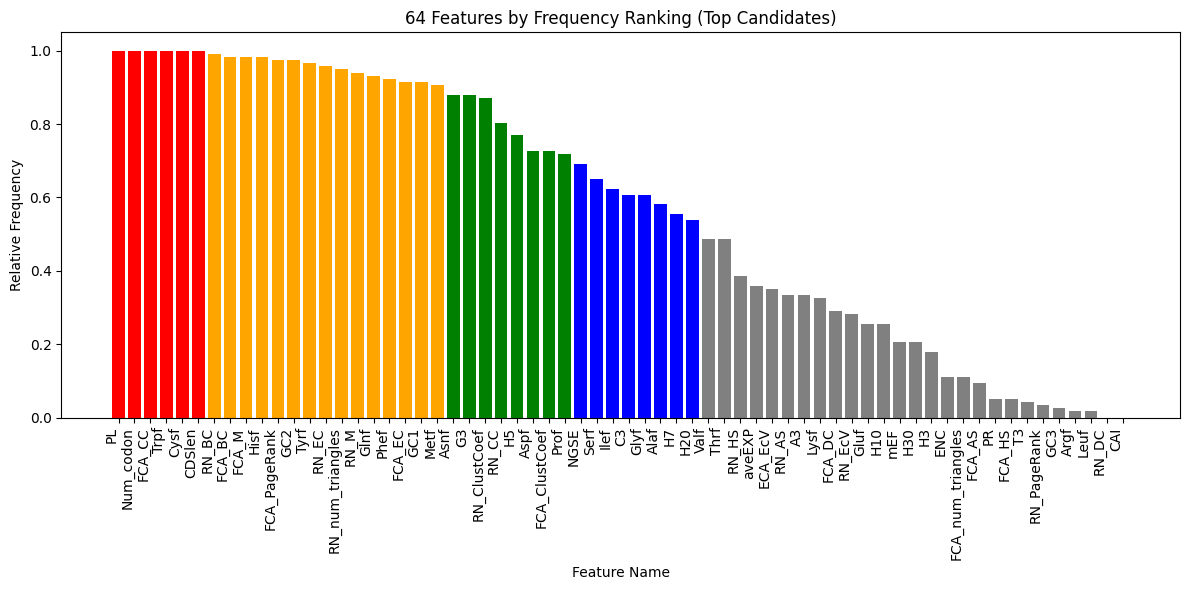

In [ ]:
import matplotlib.pyplot as plt

# ----------------------------------------------
# Visualization for Feature Frequency Ranking
# ----------------------------------------------
# Define a function to map relative_freq to discrete color bins
def get_color(freq):
    if freq == 1.0:
        return 'red'        # Color for freq == 1.0
    elif freq >= 0.9:
        return 'orange'     # Color for 0.9 <= freq < 1.0
    elif freq >= 0.7:
        return 'green'      # Color for 0.7 <= freq < 0.9
    elif freq >= 0.5:
        return 'blue'       # Color for 0.5 <= freq < 0.7
    else:
        return 'gray'       # Color for freq < 0.5

# Create a list of colors for each bar
colors = [get_color(freq) for freq in feature_freq_df['relative_freq']]

# Plot the bar chart with the custom color mapping
plt.figure(figsize=(12, 6))
plt.bar(feature_freq_df['feature_name'], feature_freq_df['relative_freq'], color=colors)

plt.xlabel('Feature Name')
plt.ylabel('Relative Frequency')
plt.title('64 Features by Frequency Ranking (Top Candidates)')

plt.xticks(rotation=90, ha='right')
plt.tight_layout()

output_fig_path = '/content/drive/MyDrive/CSI5180_Project/results/Feature_Frequency_Ranking.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import os
import shutil
import random
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from concurrent.futures import ProcessPoolExecutor, as_completed

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Define dataset storage paths
drive_folder = '/content/drive/MyDrive/CSI5180_Project/balanced_datasets'
local_folder = '/content/balanced_datasets'

# Ensure local directory exists
os.makedirs(local_folder, exist_ok=True)

# Copy data from Google Drive to local storage
shutil.copytree(drive_folder, local_folder, dirs_exist_ok=True)

print("Data copied to /content/balanced_datasets. Training is no longer affected by Google Drive API limitations.")

# Randomly select 500 datasets for analysis
sampled_df_analysis = summary_df.sample(n=500, random_state=RANDOM_STATE)

# Load selected datasets
eval_datasets_analysis = {}
for _, row in sampled_df_analysis.iterrows():
    dataset_path = os.path.join(local_folder, row['dataset'])
    try:
        df = pd.read_csv(dataset_path)
        eval_datasets_analysis[row['dataset']] = df
    except Exception as e:
        print(f"Failed to load dataset {row['dataset']}: {e}")

# Preprocess datasets
processed_datasets = {}
all_features = feature_freq_df['feature_name'].tolist()

for ds_name, df in eval_datasets_analysis.items():
    try:
        X = df[all_features]
        y = df['Class']

        # Map target variable
        mapping = {'E': 1, 'N': 0}
        y = y.map(mapping)
        if y.isnull().any():
            raise ValueError("NaN values found after mapping target variable")

        # Convert data types for memory efficiency
        processed_datasets[ds_name] = {
            'features': X.astype(np.float32),
            'target': y.astype(np.int8)
        }
    except Exception as e:
        print(f"Skipped dataset {ds_name}: {str(e)}")

print(f"Successfully processed {len(processed_datasets)} datasets.")

Data copied to /content/balanced_datasets. Training is no longer affected by Google Drive API limitations.
Successfully processed 500 datasets.


In [ ]:
# ----------------------------------------
# Function to Process a Single Dataset
# ----------------------------------------
def process_single_dataset_for_curve(ds_name, selected_features):
    """
    Train and evaluate the LinearSVC model (with calibration) on one dataset using 10-fold cross-validation.

    Parameters:
    - ds_name: The key identifying the dataset in the global processed_datasets dictionary.
    - selected_features: A list of features selected for model training.

    Returns:
    - The mean AUC score computed across all 10 folds.
    """

    try:
        # Load the dataset using the given key
        data = processed_datasets[ds_name]
        # Select the features and target from the dataset
        X = data['features'][selected_features]
        y = data['target']

        # Standardize the features for better model performance
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Set up a 10-fold stratified cross-validation
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
        fold_auc_scores = []

        # Iterate over each fold in the cross-validation
        for train_idx, test_idx in cv.split(X_scaled, y):
            # Initialize the LinearSVC model with specified parameters
            model = LinearSVC(
                random_state=RANDOM_STATE,
                dual=False,
                max_iter=1000
            )
            # Use CalibratedClassifierCV to calibrate probabilities from LinearSVC
            calibrated_model = CalibratedClassifierCV(model, method='sigmoid')

            # Split data into training and testing sets for the current fold
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Fit the model on the training set and predict probabilities for the positive class on the test set
            calibrated_model.fit(X_train, y_train)
            probabilities = calibrated_model.predict_proba(X_test)[:, 1]

            # Compute AUC score for the current fold and store it
            fold_auc_scores.append(roc_auc_score(y_test, probabilities))

            # Delete variables to free memory resources after each fold
            del model, calibrated_model, X_train, X_test, y_train, y_test, probabilities

        # Delete large variables that are no longer needed
        del X_scaled, X, scaler

        # Return the mean AUC score across all folds
        return np.mean(fold_auc_scores)

    except Exception as err:
        # Print the error message if processing fails for this dataset
        print(f"Error processing dataset {ds_name}: {err}")
        return np.nan

# -----------------------------------------------
# Evaluation Function Using Parallel Processing
# -----------------------------------------------
def evaluate_feature_combination(n_features):
    """
    Evaluate a set of features by computing the average AUC score across multiple datasets using parallel processing.

    Parameters:
    - n_features: The number of top-ranked features to include.

    Returns:
    - The overall average AUC score across the sampled datasets.
    """

    # Select the top n_features based on feature frequency ranking
    selected_features = feature_freq_df['feature_name'].head(n_features).tolist()
    auc_scores = []
    counter = 0

    # Create a progress bar for tracking dataset processing
    with tqdm(total=len(sampled_dataset_keys), desc="Processing:", dynamic_ncols=True) as pbar:
        # Initialize a ProcessPoolExecutor with max_workers set to 2 (appropriate for Colab environment)
        with ProcessPoolExecutor(max_workers=2) as executor:
            # Submit tasks for each dataset in the sampled_dataset_keys list
            futures = {executor.submit(process_single_dataset_for_curve, ds_name, selected_features): ds_name
                       for ds_name in sampled_dataset_keys}

            # As tasks complete, collect their results
            for future in as_completed(futures):
                auc_scores.append(future.result())
                counter += 1
                # Perform memory cleanup every 5 datasets processed
                if counter % 5 == 0:
                    gc.collect()
                # Update progress bar after processing each dataset
                pbar.update(1)

    # Filter out any invalid auROC results (NaN) and compute the overall average
    valid_auc = [score for score in auc_scores if not np.isnan(score)]
    return np.mean(valid_auc) if valid_auc else np.nan

In [ ]:
# ---------------------------
# Main Evaluation Loop
# ---------------------------
# Randomly select a subset of datasets for small-scale testing by sampling without replacement, with the size can be set up to 500
sampled_dataset_keys = np.random.choice(list(processed_datasets.keys()), size=500, replace=False)

# Define the feature selection range:
# The minimum number of features is determined by the smallest 'best_k' value in ranking_df.
# The maximum number of features is the count of features in feature_freq_df with relative_freq > 0.4.
min_feature_count = int(ranking_df['best_k'].min())
max_feature_count = feature_freq_df[feature_freq_df['relative_freq'] > 0.4].shape[0]

# Create a list of feature counts to evaluate
feature_range = list(range(min_feature_count, max_feature_count + 1))
print(f"Evaluating the number of frequency-ranked features from {min_feature_count} to {max_feature_count}")

performance_results = []

# The external loop only prints a message for the current feature combination.
# A separate progress bar is displayed within evaluate_feature_combination.
for idx, n_features in enumerate(feature_range, start=1):
    print(f"\nNumber of Frequency-Ranked Features = {n_features} [{idx}/{len(feature_range)}]")

    # Evaluate the current feature set and calculate the average AUC
    avg_auc = evaluate_feature_combination(n_features)
    performance_results.append({
        'n_features': n_features,
        'avg_auc': avg_auc
    })

    # Print the evaluation result with the calculated average auROC score formatted to 5 decimal places.
    print(f"Average auROC = {avg_auc:.5f}")

# Convert the performance results into a DataFrame for further analysis
performance_results_df = pd.DataFrame(performance_results)

# Save results for further analysis
output_performance_results_path = '/content/drive/MyDrive/CSI5180_Project/results/BFC_Performance_Results.csv'
performance_results_df.to_csv(output_performance_results_path, index=False)

# Final memory cleanup to free up disk and memory resources after all operations
gc.collect()

Evaluating the number of frequency-ranked features from 19 to 39

Number of Frequency-Ranked Features = 19 [1/21]


Processing:: 100%|██████████| 500/500 [03:04<00:00,  2.72it/s]


Average auROC = 0.84376

Number of Frequency-Ranked Features = 20 [2/21]


Processing:: 100%|██████████| 500/500 [03:10<00:00,  2.63it/s]


Average auROC = 0.84366

Number of Frequency-Ranked Features = 21 [3/21]


...

Processing:: 100%|██████████| 500/500 [04:39<00:00,  1.79it/s]


Average auROC = 0.90249

Number of Frequency-Ranked Features = 39 [21/21]


Processing:: 100%|██████████| 500/500 [04:59<00:00,  1.67it/s]


Average auROC = 0.90215


0

## Visualization: Incremental Frequency-Based BFC Selection Curve

After plotting feature count vs. auROC to identify the optimal number of features for classification, two key points are analyzed:
-	**Global Elbow Point**: The feature count where the auROC increase is maximized, indicating a significant performance gain.
- **Best Balance Point**: The feature count where auROC stabilizes (above a predefined threshold), representing an optimal trade-off between complexity and performance.

The curve helps visualize diminishing returns in feature selection, ensuring that additional features do not introduce unnecessary complexity without significant performance improvement.

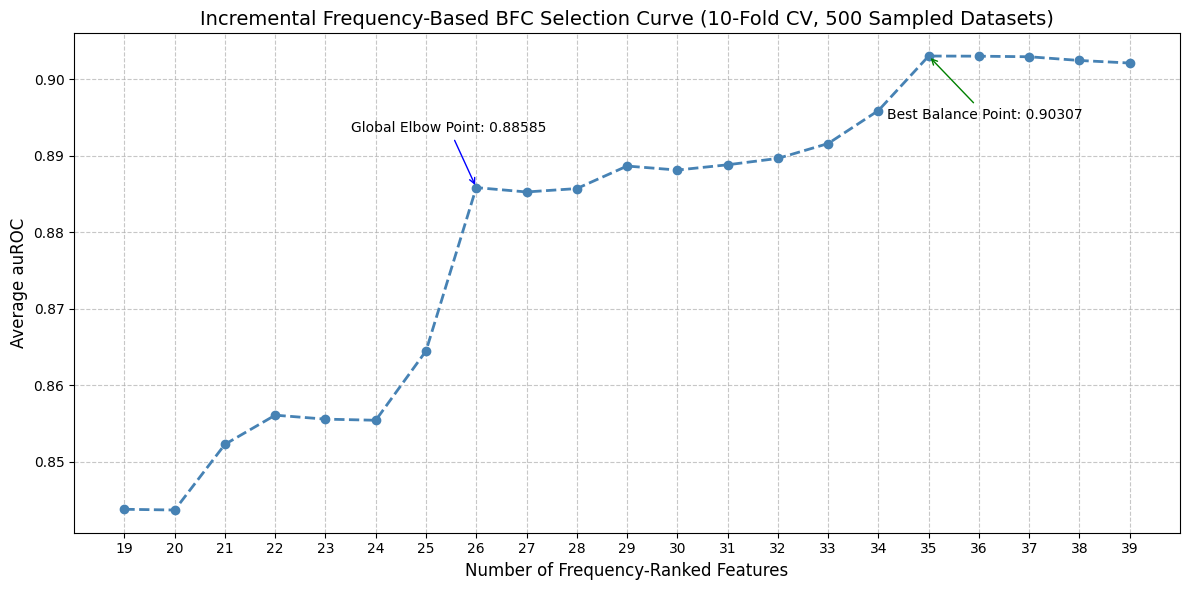

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_elbow_points(results_df, auc_threshold=0.89):
    """
    Compute two elbow points:
    - Global elbow: the point with the maximum increase in avg_auc over all data.
    - Best balance: the elbow point from the subset where avg_auc >= auc_threshold.

    Parameters:
    - results_df: DataFrame with columns ['n_features', 'avg_auc'].
    - auc_threshold: AUC threshold for computing the best balance point (default 0.89).

    Returns:
    - global_elbow_point, global_elbow_auc, best_balance_point, best_balance_auc
    """

    # Create a copy of results_df to avoid modifying the original DataFrame
    df = results_df.copy()

    # Global elbow point
    df['auc_diff'] = df['avg_auc'].diff()
    global_elbow_index = df['auc_diff'].idxmax()
    global_elbow_point = df.loc[global_elbow_index, 'n_features']
    global_elbow_auc = df.loc[global_elbow_index, 'avg_auc']

    # Best balance point (subset where avg_auc >= auc_threshold)
    df_sub = df[df['avg_auc'] >= auc_threshold].copy()
    df_sub.reset_index(drop=True, inplace=True)

    # Check if there is more than one row in the subset DataFrame
    if len(df_sub) > 1:
         # Compute the difference in AUC between consecutive rows
        df_sub['auc_diff'] = df_sub['avg_auc'].diff()

        # Find the index where the AUC difference is the largest
        best_balance_index = df_sub['auc_diff'].idxmax()

        # Get the corresponding number of features and AUC value at this balance point
        best_balance_point = df_sub.loc[best_balance_index, 'n_features']
        best_balance_auc = df_sub.loc[best_balance_index, 'avg_auc']

    # If there is only one row or none, set the values to NaN
    else:
        best_balance_point = np.nan
        best_balance_auc = np.nan

    return global_elbow_point, global_elbow_auc, best_balance_point, best_balance_auc

# Load the dataset
performance_results_df = pd.read_csv('/content/drive/MyDrive/CSI5180_Project/results/BFC_Performance_Results.csv')

# Compute elbow points for feature selection analysis
global_elbow_point, global_elbow_auc, best_balance_point, best_balance_auc = compute_elbow_points(performance_results_df, auc_threshold=0.89)

# Plot the relationship between the number of selected features and the average AUC score.
plt.figure(figsize=(12, 6))
plt.plot(performance_results_df['n_features'], performance_results_df['avg_auc'], marker='o', linestyle='--', color='steelblue', linewidth=2)
plt.xlabel('Number of Frequency-Ranked Features', fontsize=12)
plt.ylabel('Average auROC', fontsize=12)
plt.title('Incremental Frequency-Based BFC Selection Curve (10-Fold CV, 500 Sampled Datasets)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(performance_results_df['n_features'], rotation=0)
plt.tight_layout()

# Annotate global elbow point
plt.annotate(
    f'Global Elbow Point: {global_elbow_auc:.5f}',
    xy=(global_elbow_point, global_elbow_auc),
    xytext=(-90, 40),
    textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color='blue')
)

# Annotate best balance point
if not np.isnan(best_balance_point):
    plt.annotate(
        f'Best Balance Point: {best_balance_auc:.5f}',
        xy=(best_balance_point, best_balance_auc),
        xytext=(-30, -45),
        textcoords='offset points',
        arrowprops=dict(arrowstyle="->", color='green')
    )

output_fig_path = '/content/drive/MyDrive/CSI5180_Project/results/BFC_Selection_Curve.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()